In [2]:
!pip install tensorflow


In [3]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [4]:
df = pd.read_csv("train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
x = df.drop("label",axis = 1)
y = df['label']

In [6]:
x = x/255.0

In [7]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state= 42)


**MODEL 1 :- PERCEPTRON**

In [8]:
per_model = Perceptron()
per_model.fit(x_train , y_train)


Perceptron()

In [9]:
y_pred1 = per_model.predict(x_test)
accuracy = accuracy_score(y_test , y_pred1)

In [10]:
accuracy

0.8796428571428572

**MODEL 2 :- ANN(DENSE NURAL NETWORK)**

In [14]:
from tensorflow import keras
from tensorflow.keras import layers
ann_model = keras.Sequential([
    layers.Dense(128 , activation = 'relu' , input_shape=(784,)), 
    layers.Dense(64 , activation = 'relu'),
    layers.Dense(10 , activation = 'softmax')
])

In [15]:
ann_model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [16]:
ann_model.fit(x_train , y_train , epochs=10, batch_size=32 , verbose=1)
_ , acc_ann = ann_model.evaluate(x_test , y_test)

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9097 - loss: 0.3019
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9621 - loss: 0.1267
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9739 - loss: 0.0860
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9808 - loss: 0.0621
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0487
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9877 - loss: 0.0386
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9891 - loss: 0.0324
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9911 - loss: 0.0261
Epoch 9/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9938 - loss: 0.0194
Epoch 10/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9940 - loss: 0.0186
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9740 - loss: 0.1051   


In [17]:
print("ANN Accuracy:" ,acc_ann )

ANN Accuracy: 0.9740476012229919


**MODEL 3 :- USING CNN**

In [18]:
x_train_cnn = x_train.values.reshape(-1,28,28,1)
x_test_cnn = x_test.values.reshape(-1,28,28,1)

In [20]:
cnn_model = keras.Sequential([
    layers.Conv2D(32,(3,3), activation="relu" , input_shape = (28,28,1)),
    layers.MaxPooling2D((2,2)) , 

    layers.Conv2D(64,(3,3), activation="relu"), 
    layers.MaxPooling2D((2,2)), 

    layers.Flatten(), 
    layers.Dense(64 , activation="relu"),
    layers.Dense(10 , activation="softmax")
    
])

In [21]:
cnn_model.compile(
    optimizer="adam", 
    loss = "sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

In [23]:
cnn_model.fit(x_train_cnn , y_train , epochs=5 , verbose=1)
_, acc_cnn = cnn_model.evaluate(x_test_cnn , y_test)

Epoch 1/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9930 - loss: 0.0203
Epoch 2/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9949 - loss: 0.0160
Epoch 3/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9949 - loss: 0.0141
Epoch 4/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9965 - loss: 0.0108
Epoch 5/5
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9969 - loss: 0.0094
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0512   


In [24]:
print("Accuracy Score:-" , acc_cnn)

Accuracy Score:- 0.9877380728721619


**Visualize All Accuracies**

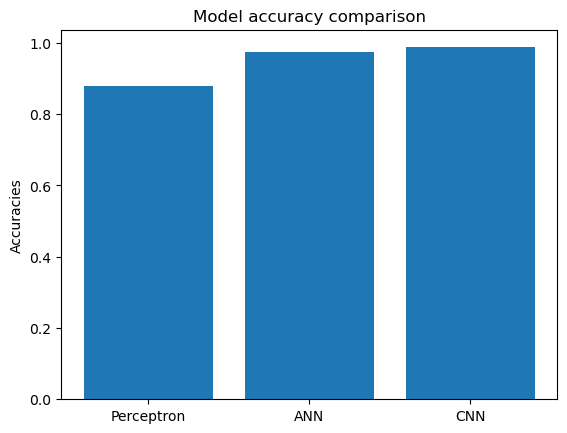

In [27]:
models = ["Perceptron" , "ANN" , "CNN"]
Accuracies = [accuracy , acc_ann , acc_cnn]  

plt.bar(models , Accuracies)
plt.title("Model accuracy comparison") 
plt.ylabel("Accuracies")
plt.show()